# Actividad 03 — Actividad 2: Hyperparameter Tuning con PSO

**Algoritmo de enjambre:** Particle Swarm Optimization (PSO)  
**Modelo:** Random Forest Classifier  
**Dataset:** Mushrooms (UCI Machine Learning Repository)  
**Objetivo:** Encontrar los mejores hiperparámetros del modelo sin búsqueda exhaustiva.

---

## 1. Instalación y librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Carga y preprocesamiento del dataset

> **Opción A:** Cargar desde Google Drive (recomendado si ya tienes el CSV ahí)  
> **Opción B:** Descargar directamente desde URL

In [ ]:
# ── OPCIÓN A: Desde Google Drive ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje_maquina/mushrooms.csv')

# ── OPCIÓN B: Desde URL (descarga directa) ────────────────────
#url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/mushrooms.csv"
#df = pd.read_csv(url)

print(f"Shape del dataset: {df.shape}")
print(f"\nDistribución de clases:")
print(df['class'].value_counts())
df.head()

Mounted at /content/drive
Shape del dataset: (8124, 23)

Distribución de clases:
class
e    4208
p    3916
Name: count, dtype: int64


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
# Codificación de variables categóricas con LabelEncoder
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)

X = df_encoded.drop('class', axis=1).values
y = df_encoded['class'].values

print(f"Features: {X.shape[1]} columnas")
print(f"Muestras: {X.shape[0]} filas")
print(f"Clases:   {np.unique(y)}  (0=comestible, 1=venenoso)")

Features: 22 columnas
Muestras: 8124 filas
Clases:   [0 1]  (0=comestible, 1=venenoso)


## 3. Espacio de búsqueda de hiperparámetros

Cada partícula del enjambre es un vector de 5 dimensiones:

| Dim | Hiperparámetro | Rango |
|-----|---------------|-------|
| 0 | `n_estimators` | [10, 300] |
| 1 | `max_depth` | [2, 30] |
| 2 | `min_samples_split` | [2, 20] |
| 3 | `min_samples_leaf` | [1, 10] |
| 4 | `max_features` | [0.1, 1.0] |

In [ ]:
BOUNDS_LOW  = np.array([10,  2,  2, 1, 0.1])
BOUNDS_HIGH = np.array([300, 30, 20, 10, 1.0])

def decode_particle(position):
    """Convierte vector continuo a hiperparámetros válidos."""
    pos = np.clip(position, BOUNDS_LOW, BOUNDS_HIGH)
    return {
        'n_estimators':      int(round(pos[0])),
        'max_depth':         int(round(pos[1])),
        'min_samples_split': int(round(pos[2])),
        'min_samples_leaf':  int(round(pos[3])),
        'max_features':      float(pos[4]),
    }

print('✅ Espacio de búsqueda definido')

✅ Espacio de búsqueda definido


## 4. Función de aptitud (Fitness)

$$fitness(x_i) = 1 - \overline{CV\_Accuracy}(RF(decode(x_i)))$$

PSO **minimiza** → retornamos `1 - accuracy` (minimizar error = maximizar accuracy).

In [ ]:
def fitness_function(position):
    """
    Evalúa la aptitud de una partícula.
    Usa validación cruzada estratificada de 3 folds.
    Retorna el error (1 - accuracy) para minimizar.
    """
    params = decode_particle(position)
    clf = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
    return 1.0 - np.mean(scores)

print('✅ Función de aptitud definida')

✅ Función de aptitud definida


## 5. Implementación PSO — Ciclo completo del algoritmo

```
PASO 1: Representación  → vector 5D por partícula
PASO 2: Inicialización  → posiciones y velocidades aleatorias
PASO 3: Fitness         → cross_val_score del Random Forest
PASO 4: Comportamiento  → actualizar v y x con pbest/gbest
PASO 5: Evolución       → repetir N iteraciones
PASO 6: Finalización    → convergencia o máx. iteraciones
```

In [ ]:
class PSO:
    """
    Particle Swarm Optimization para Hyperparameter Tuning.
    Implementación desde cero siguiendo el ciclo completo del algoritmo.
    """

    def __init__(self, n_particles=20, n_iter=40, w=0.9, c1=1.5, c2=1.5, verbose=True):
        self.n_particles = n_particles  # Tamaño del enjambre
        self.n_iter      = n_iter       # Iteraciones máximas
        self.w  = w    # Inercia
        self.c1 = c1   # Coeficiente cognitivo
        self.c2 = c2   # Coeficiente social
        self.dim = len(BOUNDS_LOW)      # Dimensiones del espacio
        self.verbose = verbose

        self.history_best  = []
        self.history_mean  = []

    # ── PASO 1 & 2: Representación e Inicialización ──────────
    def _initialize(self):
        self.positions  = np.random.uniform(BOUNDS_LOW, BOUNDS_HIGH,
                                            size=(self.n_particles, self.dim))
        vel_range       = (BOUNDS_HIGH - BOUNDS_LOW) * 0.1
        self.velocities = np.random.uniform(-vel_range, vel_range,
                                            size=(self.n_particles, self.dim))
        self.pbest_pos  = self.positions.copy()
        self.pbest_fit  = np.full(self.n_particles, np.inf)
        self.gbest_pos  = None
        self.gbest_fit  = np.inf

    # ── PASO 3: Evaluación ────────────────────────────────────
    def _evaluate(self):
        fits = np.array([fitness_function(p) for p in self.positions])
        for i, f in enumerate(fits):
            if f < self.pbest_fit[i]:
                self.pbest_fit[i] = f
                self.pbest_pos[i] = self.positions[i].copy()
            if f < self.gbest_fit:
                self.gbest_fit = f
                self.gbest_pos = self.positions[i].copy()
        return fits

    # ── PASO 4: Comportamiento de la partícula ────────────────
    def _update(self):
        r1 = np.random.rand(self.n_particles, self.dim)
        r2 = np.random.rand(self.n_particles, self.dim)

        # v(t+1) = w·v(t) + c1·r1·(pbest - x) + c2·r2·(gbest - x)
        cognitive       = self.c1 * r1 * (self.pbest_pos - self.positions)
        social          = self.c2 * r2 * (self.gbest_pos  - self.positions)
        self.velocities = self.w * self.velocities + cognitive + social

        # x(t+1) = x(t) + v(t+1)
        self.positions  = np.clip(self.positions + self.velocities,
                                  BOUNDS_LOW, BOUNDS_HIGH)

    # ── PASO 5 & 6: Evolución y Finalización ─────────────────
    def optimize(self):
        print('=' * 55)
        print(f'  PSO | {self.n_particles} partículas | {self.n_iter} iteraciones')
        print('=' * 55)

        self._initialize()
        fits = self._evaluate()
        self.history_best.append(self.gbest_fit)
        self.history_mean.append(np.mean(fits))
        if self.verbose:
            print(f'[Init] Accuracy: {1-self.gbest_fit:.4f}')

        for it in range(1, self.n_iter + 1):
            # Decaimiento lineal de inercia: 0.9 → 0.4
            self.w = 0.9 - 0.5 * it / self.n_iter

            self._update()
            fits = self._evaluate()
            self.history_best.append(self.gbest_fit)
            self.history_mean.append(np.mean(fits))

            if self.verbose and (it % 5 == 0 or it == 1):
                print(f'[Iter {it:3d}] Best Acc: {1-self.gbest_fit:.4f} | '
                      f'Mean Acc: {1-np.mean(fits):.4f} | w={self.w:.3f}')

            # Criterio de parada temprana
            if self.gbest_fit < 0.001:
                print(f'\n⚡ Convergencia en iteración {it}')
                break

        print('\n' + '=' * 55)
        best_params = decode_particle(self.gbest_pos)
        print(f'  Accuracy final (CV): {1-self.gbest_fit:.4f}')
        print(f'  Mejores hiperparámetros:')
        for k, v in best_params.items():
            print(f'    {k}: {v}')
        print('=' * 55)
        return best_params

print('✅ Clase PSO definida')

✅ Clase PSO definida


## 6. Ejecución del PSO

> ⏱️ Puede tomar 3-8 minutos dependiendo del hardware de Colab.

In [ ]:
pso = PSO(n_particles=20, n_iter=40, w=0.9, c1=1.5, c2=1.5, verbose=True)
best_params = pso.optimize()

  PSO | 20 partículas | 40 iteraciones
[Init] Accuracy: 1.0000
[Iter   1] Best Acc: 1.0000 | Mean Acc: 0.9998 | w=0.888

⚡ Convergencia en iteración 1

  Accuracy final (CV): 1.0000
  Mejores hiperparámetros:
    n_estimators: 209
    max_depth: 27
    min_samples_split: 7
    min_samples_leaf: 7
    max_features: 0.9444472359747479


## 7. Evaluación del modelo final

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

final_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(f'Accuracy en Test Set: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['comestible', 'venenoso']))

Accuracy en Test Set: 1.0000

Classification Report:
              precision    recall  f1-score   support

  comestible       1.00      1.00      1.00       842
    venenoso       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## 8. Comparación: Default RF vs PSO RF

In [ ]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

default_model = RandomForestClassifier(random_state=42, n_jobs=-1)
default_cv    = cross_val_score(default_model, X, y, cv=cv5, scoring='accuracy')
pso_cv        = cross_val_score(final_model,   X, y, cv=cv5, scoring='accuracy')

print('── Comparación (5-Fold CV) ──────────────────────────')
print(f'Default RF → {np.mean(default_cv):.4f} ± {np.std(default_cv):.4f}')
print(f'PSO RF     → {np.mean(pso_cv):.4f} ± {np.std(pso_cv):.4f}')
print(f'Mejora:      {(np.mean(pso_cv)-np.mean(default_cv))*100:.4f}%')

── Comparación (5-Fold CV) ──────────────────────────
Default RF → 1.0000 ± 0.0000
PSO RF     → 1.0000 ± 0.0000
Mejora:      0.0000%


## 9. Visualizaciones

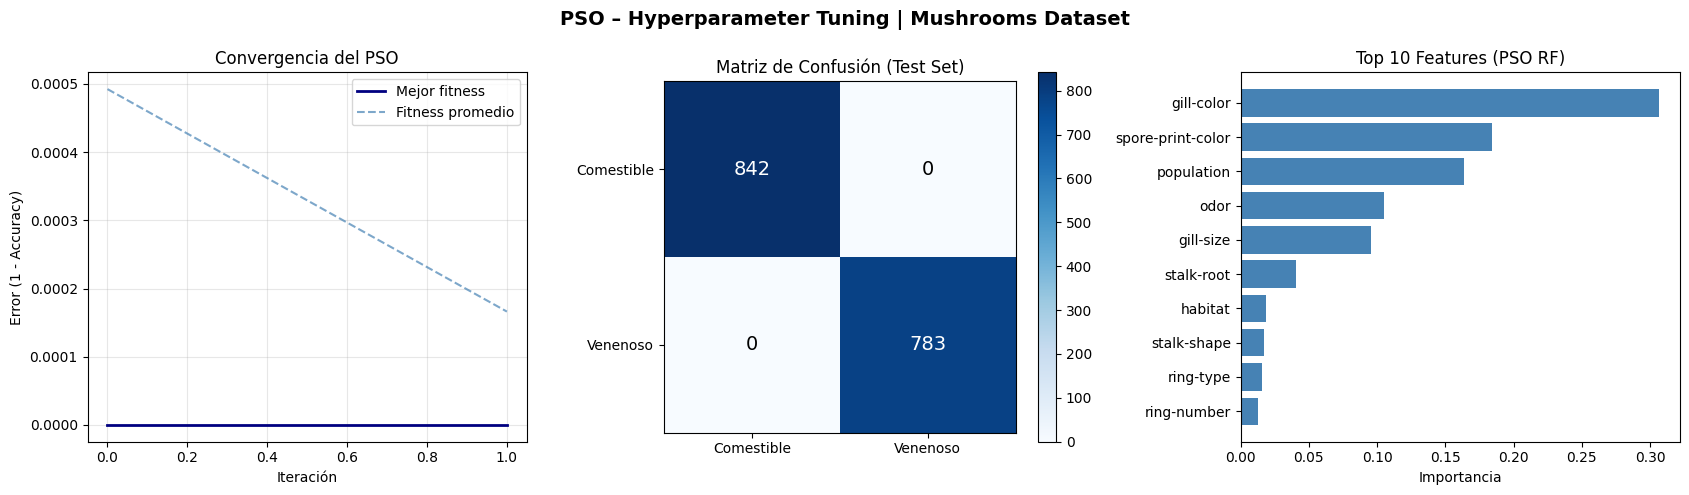

✅ Gráfica guardada como pso_resultados.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('PSO – Hyperparameter Tuning | Mushrooms Dataset', fontsize=14, fontweight='bold')

# Curva de convergencia
axes[0].plot(pso.history_best, label='Mejor fitness', color='navy', lw=2)
axes[0].plot(pso.history_mean, label='Fitness promedio', color='steelblue', ls='--', alpha=0.7)
axes[0].set_title('Convergencia del PSO')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Error (1 - Accuracy)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('Matriz de Confusión (Test Set)')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Comestible','Venenoso'])
axes[1].set_yticklabels(['Comestible','Venenoso'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[1])

# Top 10 features
importances = final_model.feature_importances_
feat_names  = df.drop('class', axis=1).columns
top_idx     = np.argsort(importances)[-10:]
axes[2].barh(feat_names[top_idx], importances[top_idx], color='steelblue')
axes[2].set_title('Top 10 Features (PSO RF)')
axes[2].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('pso_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada como pso_resultados.png')